In [1]:
# ============================================================
# GLOBAL MODEL INPUTS
# Change the values here to update all model blocks below.
# ============================================================

S0 = 1_283_903          # Initial stock / car value: ₹12,83,903
K = 1_155_641           # Strike / buyback price: ₹11,55,641
r = 0.0526             # Risk-free rate: 3 months T bill rate in india
T = 3 / 12              # Time to maturity: 3 months
N = 100                 # Number of time steps

# Additional model inputs
sigma = 0.30            # Volatility used for single-scenario models
depreciation = 0.10     # Annual deterministic depreciation: 10%

import math


# ============================================================
# BASIC BINOMIAL PUT OPTION MODEL
# ============================================================

def binomial_put_option(T, N, r, sigma, S0, K):
    """Binomial Tree Pricing Model for a European Put Option."""

    dt = T / N

    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u

    p = (math.exp(r * dt) - d) / (u - d)
    discount = math.exp(-r * dt)

    if not 0 <= p <= 1:
        raise ValueError(
            "Risk-neutral probability is outside [0,1]. "
            "Try increasing the number of periods."
        )

    stock_tree = []

    for i in range(N + 1):
        row = []

        for j in range(i + 1):
            stock_price = (
                S0 *
                (u ** j) *
                (d ** (i - j))
            )
            row.append(stock_price)

        stock_tree.append(row)

    option_tree = [None] * (N + 1)

    option_tree[N] = [
        max(K - stock_price, 0)
        for stock_price in stock_tree[N]
    ]

    for i in range(N - 1, -1, -1):
        option_tree[i] = []

        for j in range(i + 1):
            value_up = option_tree[i + 1][j + 1]
            value_down = option_tree[i + 1][j]

            option_value = discount * (
                p * value_up +
                (1 - p) * value_down
            )

            option_tree[i].append(option_value)

    put_value = option_tree[0][0]

    print("\n" + "=" * 70)
    print("BINOMIAL PUT OPTION PRICING MODEL")
    print("=" * 70)

    print("\nINPUTS")
    print("-" * 70)
    print(f"Time to maturity (T) : {T}")
    print(f"Number of periods (N): {N}")
    print(f"Risk-free rate (r)   : {r * 100:.2f}%")
    print(f"Volatility (sigma)    : {sigma * 100:.2f}%")
    print(f"Initial stock price   : ₹{S0:,.2f}")
    print(f"Strike price (K)      : ₹{K:,.2f}")

    print("\nMODEL PARAMETERS")
    print("-" * 70)
    print(f"Time per period (dt)  : {dt:.6f} years")
    print(f"Up factor (u)         : {u:.6f}")
    print(f"Down factor (d)       : {d:.6f}")
    print(f"Risk-neutral p        : {p:.6f}")
    print(f"Risk-neutral (1-p)    : {1-p:.6f}")
    print(f"Discount factor       : {discount:.6f}")

    print("\nFINAL RESULTS")
    print("-" * 70)
    print(f"Initial Stock Value    : ₹{S0:,.2f}")
    print(f"Put Option Value       : ₹{put_value:,.2f}")
    print(f"Stock + Put Value      : ₹{S0 + put_value:,.2f}")

    print("\n" + "=" * 70)

    return {
        "stock_tree": stock_tree,
        "option_tree": option_tree,
        "put_value": put_value,
        "u": u,
        "d": d,
        "p": p,
        "dt": dt
    }


# ============================================================
# RUN THE MODEL USING GLOBAL INPUTS
# ============================================================

results = binomial_put_option(
    T=T,
    N=N,
    r=r,
    sigma=sigma,
    S0=S0,
    K=K
)



BINOMIAL PUT OPTION PRICING MODEL

INPUTS
----------------------------------------------------------------------
Time to maturity (T) : 0.25
Number of periods (N): 100
Risk-free rate (r)   : 5.26%
Volatility (sigma)    : 30.00%
Initial stock price   : ₹1,283,903.00
Strike price (K)      : ₹1,155,641.00

MODEL PARAMETERS
----------------------------------------------------------------------
Time per period (dt)  : 0.002500 years
Up factor (u)         : 1.015113
Down factor (d)       : 0.985112
Risk-neutral p        : 0.500634
Risk-neutral (1-p)    : 0.499366
Discount factor       : 0.999869

FINAL RESULTS
----------------------------------------------------------------------
Initial Stock Value    : ₹1,283,903.00
Put Option Value       : ₹22,311.11
Stock + Put Value      : ₹1,306,214.11



In [2]:
# ============================================================
# OPTIONAL: PRINT DETAILED TREE RESULTS
# ============================================================

# print("\n" + "=" * 70)
# print("STOCK PRICE TREE")
# print("=" * 70)

# for i in range(N + 1):
#     print(f"\nTime Step {i}:")
#     for j in range(i + 1):
#         t = i * results["dt"]
#         price = results["stock_tree"][i][j]
#         print(
#             f"  Node ({i},{j}) | "
#             f"Time = {t:.4f} years | "
#             f"Stock Price = ₹{price:,.2f}"
#         )


# print("\n" + "=" * 70)
# print("TERMINAL PUT PAYOFFS")
# print("=" * 70)

# for j, payoff in enumerate(results["option_tree"][N]):
#     stock_price = results["stock_tree"][N][j]
#     print(
#         f"Node ({N},{j}) | "
#         f"Stock Price = ₹{stock_price:,.2f} | "
#         f"Put Payoff = ₹{payoff:,.2f}"
#     )


# print("\n" + "=" * 70)
# print("BACKWARD-INDUCTION OPTION VALUES")
# print("=" * 70)

# for i in range(N + 1):
#     print(f"\nTime Step {i}:")
#     for j in range(i + 1):
#         print(
#             f"  Node ({i},{j}) | "
#             f"Option Value = ₹{results['option_tree'][i][j]:,.2f}"
#         )


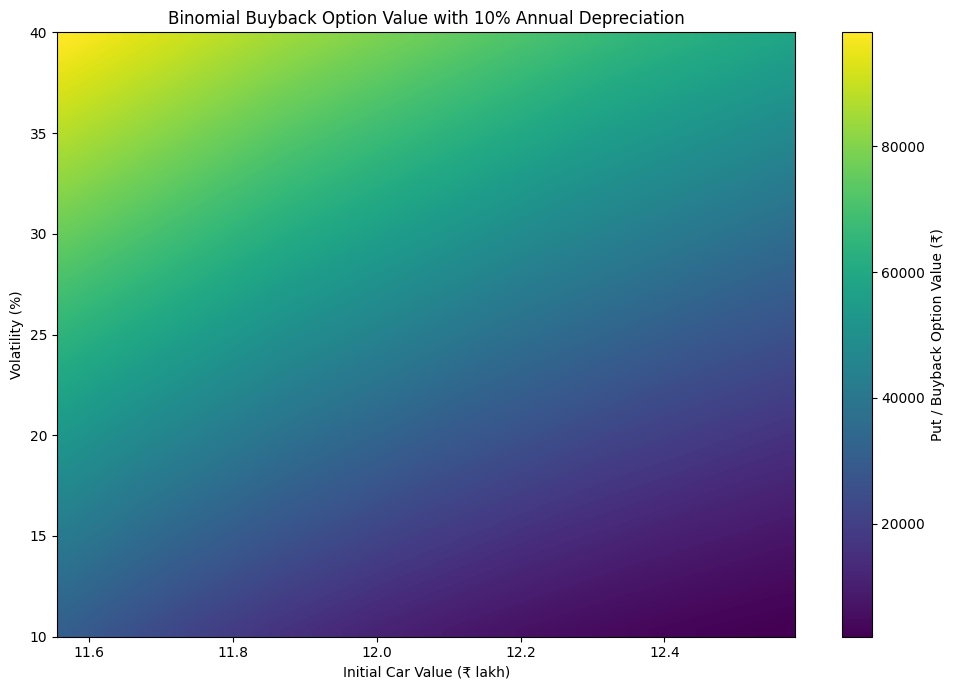


BINOMIAL HEATMAP ANALYSIS

Base Initial Stock / Car Value : ₹1,283,903
Strike / Buyback Price        : ₹1,155,641
Maturity                      : 0.2500 years (91 days)
Depreciation                  : 10.0%
Periods                       : 100

Option Value Range:
Minimum : ₹1,988.37
Maximum : ₹98,158.58


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# BINOMIAL PUT OPTION MODEL
# DETERMINISTICALLY DEPRECIATING ASSET
# ============================================================

def binomial_put_value(S0, K, T, N, r, sigma, depreciation):
    """European put on a deterministically depreciating asset."""

    dt = T / N

    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u

    # Depreciation is explicitly incorporated into stock prices,
    # so the standard CRR risk-neutral probability is used.
    p = (math.exp(r * dt) - d) / (u - d)

    terminal_prices = []
    depreciation_factor = (1 - depreciation) ** T

    for j in range(N + 1):
        stock_price = (
            S0
            * depreciation_factor
            * (u ** j)
            * (d ** (N - j))
        )
        terminal_prices.append(stock_price)

    option_values = [
        max(K - S, 0)
        for S in terminal_prices
    ]

    for i in range(N - 1, -1, -1):
        new_values = []

        for j in range(i + 1):
            value_up = option_values[j + 1]
            value_down = option_values[j]

            value = (
                math.exp(-r * dt)
                * (
                    p * value_up
                    + (1 - p) * value_down
                )
            )

            new_values.append(value)

        option_values = new_values

    return option_values[0]


# ============================================================
# PARAMETER RANGES
# ============================================================

# Same relative 90%–98% range as the earlier heatmap,
# now centered on the new global base stock price S0.
stock_price_values = np.linspace(
    0.90 * S0,
    0.98 * S0,
    41
)

volatility_values = np.linspace(0.10, 0.40, 41)


# ============================================================
# CALCULATE OPTION VALUES
# ============================================================

option_values = np.zeros(
    (len(volatility_values), len(stock_price_values))
)

for i, sigma_i in enumerate(volatility_values):

    for j, stock_price in enumerate(stock_price_values):

        option_values[i, j] = binomial_put_value(
            S0=stock_price,
            K=K,
            T=T,
            N=N,
            r=r,
            sigma=sigma_i,
            depreciation=depreciation
        )


# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(10, 7))

extent = [
    stock_price_values.min() / 100_000,
    stock_price_values.max() / 100_000,
    volatility_values.min() * 100,
    volatility_values.max() * 100
]

plt.imshow(
    option_values,
    origin="lower",
    aspect="auto",
    extent=extent,
    interpolation="bilinear"
)

plt.colorbar(label="Put / Buyback Option Value (₹)")

plt.xlabel("Initial Car Value (₹ lakh)")
plt.ylabel("Volatility (%)")

plt.title(
    "Binomial Buyback Option Value with 10% Annual Depreciation"
)

plt.tight_layout()
plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("BINOMIAL HEATMAP ANALYSIS")
print("=" * 60)

print(f"\nBase Initial Stock / Car Value : ₹{S0:,.0f}")
print(f"Strike / Buyback Price        : ₹{K:,.0f}")
print(f"Maturity                      : {T:.4f} years ({T*365:.0f} days)")
print(f"Depreciation                  : {depreciation:.1%}")
print(f"Periods                       : {N}")

print("\nOption Value Range:")
print(f"Minimum : ₹{option_values.min():,.2f}")
print(f"Maximum : ₹{option_values.max():,.2f}")


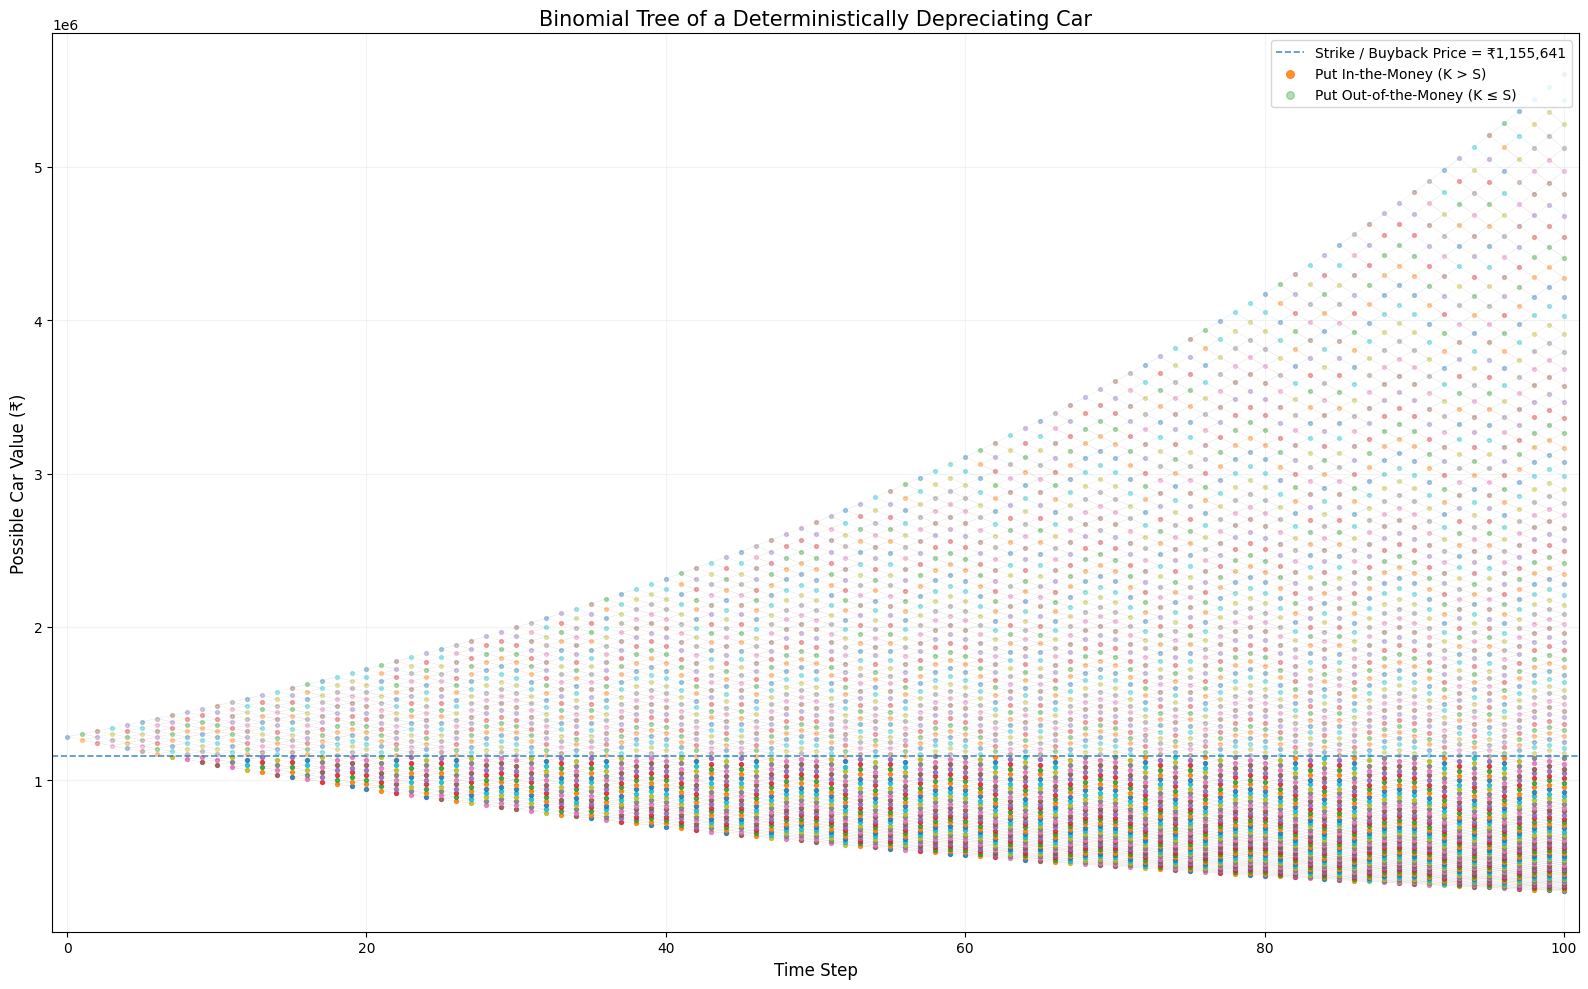


BINOMIAL TREE VISUALIZATION

Initial Asset Value     : ₹1,283,903.00
Strike / Buyback Price : ₹1,155,641.00

Time to Maturity        : 0.250000 years
Number of Periods      : 100
Risk-free Rate         : 5.26%
Volatility             : 30.00%
Annual Depreciation    : 10.00%

Up Factor (u)           : 1.015113
Down Factor (d)        : 0.985112
Risk-neutral Probability: 0.500634



In [4]:
import math
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# BINOMIAL TREE VISUALIZATION
# DETERMINISTICALLY DEPRECIATING ASSET
# ============================================================

dt = T / N

u = math.exp(sigma * math.sqrt(dt))
d = 1 / u

p = (math.exp(r * dt) - d) / (u - d)


# ============================================================
# BUILD STOCK PRICE TREE
# ============================================================

stock_tree = []

for i in range(N + 1):

    row = []
    t = i * dt
    depreciation_factor = (1 - depreciation) ** t

    for j in range(i + 1):

        stock_price = (
            S0
            * depreciation_factor
            * (u ** j)
            * (d ** (i - j))
        )

        row.append(stock_price)

    stock_tree.append(row)


# ============================================================
# BUILD PUT MONEYNESS TREE
# ============================================================

exercise_tree = []

for i in range(N + 1):

    row = []

    for j in range(i + 1):

        S = stock_tree[i][j]
        in_the_money = K > S

        row.append(in_the_money)

    exercise_tree.append(row)


# ============================================================
# CREATE PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(16, 10))


# Draw binomial connections
for i in range(N):

    for j in range(i + 1):

        x1 = i
        y1 = stock_tree[i][j]

        ax.plot(
            [x1, i + 1],
            [y1, stock_tree[i + 1][j + 1]],
            linewidth=0.25,
            alpha=0.25
        )

        ax.plot(
            [x1, i + 1],
            [y1, stock_tree[i + 1][j]],
            linewidth=0.25,
            alpha=0.25
        )


# Plot nodes
for i in range(N + 1):

    for j in range(i + 1):

        S = stock_tree[i][j]

        if exercise_tree[i][j]:

            ax.scatter(i, S, s=8, alpha=0.85)

        else:

            ax.scatter(i, S, s=8, alpha=0.35)


# Strike price line
ax.axhline(
    K,
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label=f"Strike / Buyback Price = ₹{K:,.0f}"
)


# Labels
ax.set_xlabel("Time Step", fontsize=12)
ax.set_ylabel("Possible Car Value (₹)", fontsize=12)

ax.set_title(
    "Binomial Tree of a Deterministically Depreciating Car",
    fontsize=15
)


# Legend
ax.scatter(
    [],
    [],
    s=30,
    alpha=0.85,
    label="Put In-the-Money (K > S)"
)

ax.scatter(
    [],
    [],
    s=30,
    alpha=0.35,
    label="Put Out-of-the-Money (K ≤ S)"
)

ax.legend(loc="upper right")
ax.grid(alpha=0.15)
ax.set_xlim(-1, N + 1)

plt.tight_layout()
plt.show()


# ============================================================
# PRINT MODEL INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("BINOMIAL TREE VISUALIZATION")
print("=" * 60)

print(f"\nInitial Asset Value     : ₹{S0:,.2f}")
print(f"Strike / Buyback Price : ₹{K:,.2f}")

print(f"\nTime to Maturity        : {T:.6f} years")
print(f"Number of Periods      : {N}")
print(f"Risk-free Rate         : {r:.2%}")
print(f"Volatility             : {sigma:.2%}")
print(f"Annual Depreciation    : {depreciation:.2%}")

print(f"\nUp Factor (u)           : {u:.6f}")
print(f"Down Factor (d)        : {d:.6f}")
print(f"Risk-neutral Probability: {p:.6f}")

print("\n" + "=" * 60)


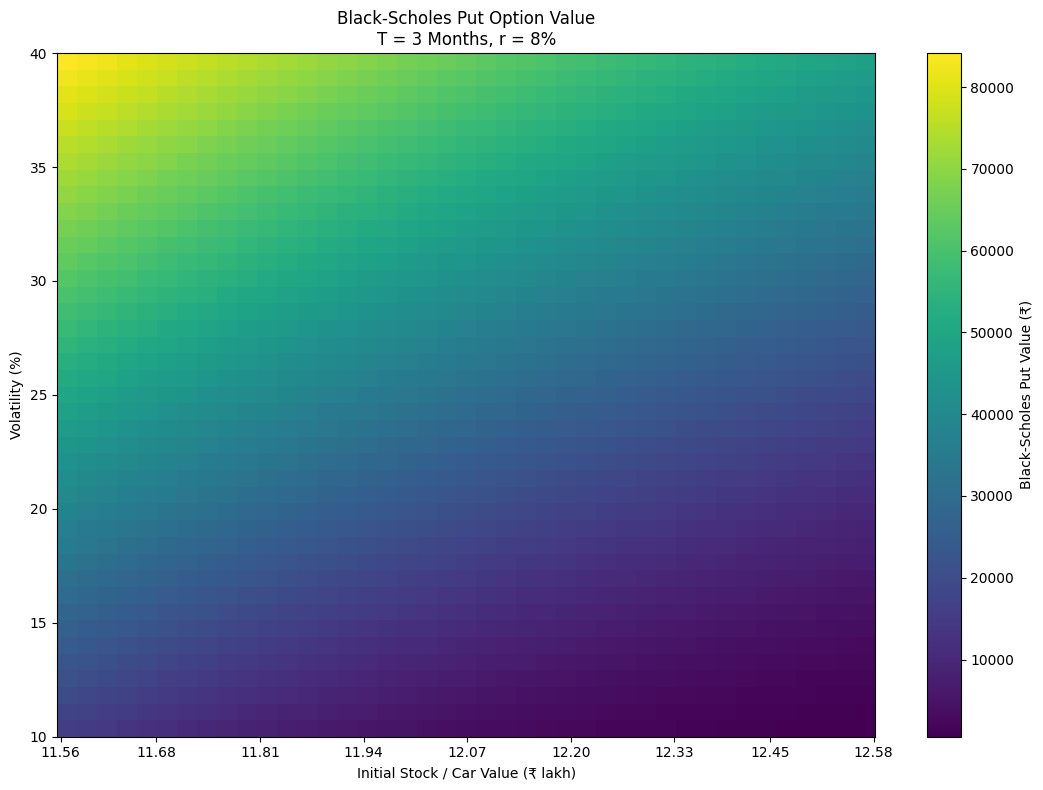


BLACK-SCHOLES PUT OPTION VALUES
At S = ₹1,283,903, Volatility = 25%:
Put Value = ₹13,904.74

At S = ₹1,219,708, Volatility = 25%:
Put Value = ₹27,492.50

At S = ₹1,155,641, Volatility = 25%:
Put Value = ₹49,982.87

Minimum option value in heatmap: ₹559.73
Maximum option value in heatmap: ₹84,156.14


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# BLACK-SCHOLES PUT OPTION
# ============================================================

def black_scholes_put(S, K, T, r, sigma):

    d1 = (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * norm.cdf(-d1)
    )


# ============================================================
# STOCK PRICE AND VOLATILITY RANGES
# ============================================================

stock_prices = np.linspace(
    0.90 * S0,
    0.98 * S0,
    41
)

volatility_values = np.linspace(0.10, 0.40, 41)


# ============================================================
# CALCULATE BLACK-SCHOLES VALUES
# ============================================================

option_values = np.zeros(
    (len(volatility_values), len(stock_prices))
)

for i, sigma_i in enumerate(volatility_values):

    for j, S in enumerate(stock_prices):

        option_values[i, j] = black_scholes_put(
            S=S,
            K=K,
            T=T,
            r=r,
            sigma=sigma_i
        )


# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(11, 8))

im = plt.imshow(
    option_values,
    origin="lower",
    aspect="auto",
    extent=[
        stock_prices[0] / 100_000,
        stock_prices[-1] / 100_000,
        volatility_values[0] * 100,
        volatility_values[-1] * 100
    ]
)

plt.colorbar(im, label="Black-Scholes Put Value (₹)")

plt.xlabel("Initial Stock / Car Value (₹ lakh)")
plt.ylabel("Volatility (%)")

plt.title(
    "Black-Scholes Put Option Value\n"
    "T = 3 Months, r = 8%"
)

plt.xticks(
    np.round(
        np.linspace(
            stock_prices[0] / 100_000,
            stock_prices[-1] / 100_000,
            9
        ),
        2
    )
)

plt.yticks(np.arange(10, 41, 5))

plt.tight_layout()
plt.show()


# ============================================================
# SAMPLE RESULTS
# ============================================================

print("\nBLACK-SCHOLES PUT OPTION VALUES")
print("=" * 50)

for S in [S0, 0.95 * S0, K]:

    value = black_scholes_put(
        S=S,
        K=K,
        T=T,
        r=r,
        sigma=0.25
    )

    print(
        f"At S = ₹{S:,.0f}, Volatility = 25%:"
        f"\nPut Value = ₹{value:,.2f}\n"
    )

print("=" * 50)
print(
    f"Minimum option value in heatmap: "
    f"₹{option_values.min():,.2f}"
)

print(
    f"Maximum option value in heatmap: "
    f"₹{option_values.max():,.2f}"
)


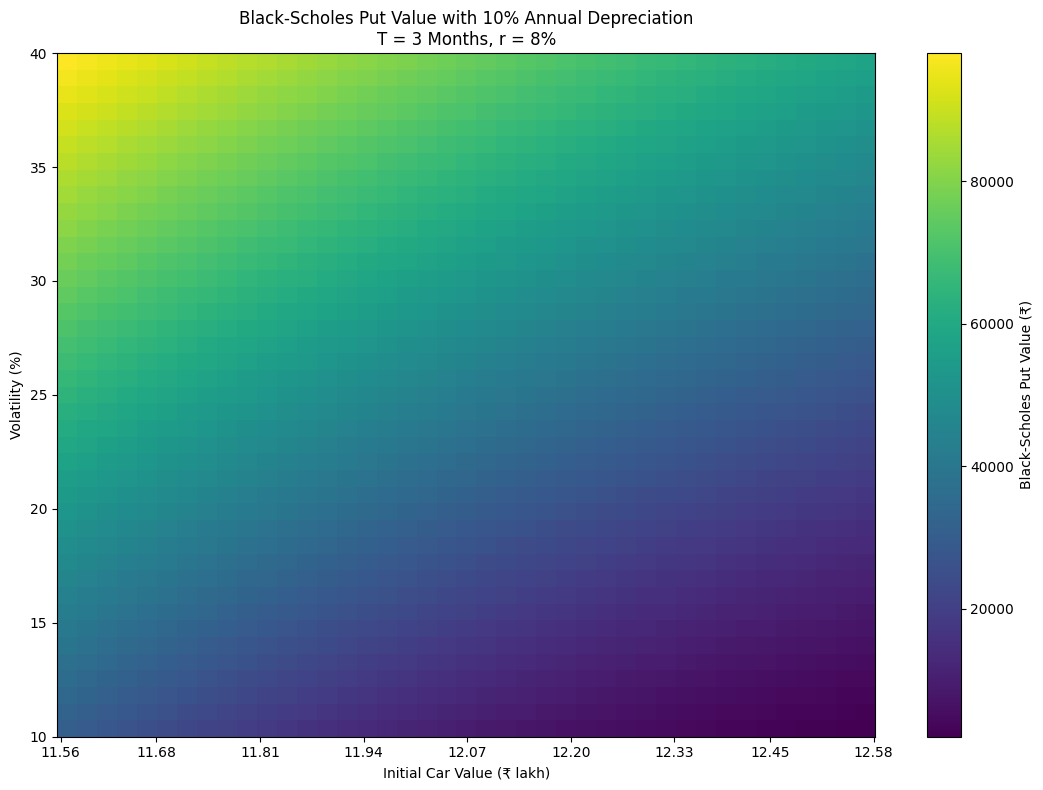


DEPRECIATION
Annual simple depreciation: 10.00%
Equivalent continuous depreciation rate: 10.536% p.a.

BLACK-SCHOLES PUT VALUES WITH DEPRECIATION
Volatility =  10.0% → Put Value = ₹767.79
Volatility =  20.0% → Put Value = ₹11,539.29
Volatility =  25.0% → Put Value = ₹20,020.32
Volatility =  30.0% → Put Value = ₹29,502.19
Volatility =  40.0% → Put Value = ₹50,112.23

Minimum heatmap value: ₹1,995.86
Maximum heatmap value: ₹97,984.48


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


# ============================================================
# BLACK-SCHOLES PUT WITH DETERMINISTIC DEPRECIATION
# ============================================================

def black_scholes_put_depreciating(
    S, K, T, r, sigma, depreciation
):
    """
    Black-Scholes European put with deterministic
    proportional depreciation.
    """

    q = -np.log(1 - depreciation)

    d1 = (
        np.log(S / K)
        + (r - q + 0.5 * sigma**2) * T
    ) / (sigma * np.sqrt(T))

    d2 = d1 - sigma * np.sqrt(T)

    return (
        K * np.exp(-r * T) * norm.cdf(-d2)
        - S * np.exp(-q * T) * norm.cdf(-d1)
    )


# ============================================================
# STOCK PRICE AND VOLATILITY RANGES
# ============================================================

stock_prices = np.linspace(
    0.90 * S0,
    0.98 * S0,
    41
)

volatility_values = np.linspace(0.10, 0.40, 41)


# ============================================================
# CALCULATE OPTION VALUES
# ============================================================

option_values = np.zeros(
    (len(volatility_values), len(stock_prices))
)

for i, sigma_i in enumerate(volatility_values):

    for j, S in enumerate(stock_prices):

        option_values[i, j] = (
            black_scholes_put_depreciating(
                S=S,
                K=K,
                T=T,
                r=r,
                sigma=sigma_i,
                depreciation=depreciation
            )
        )


# ============================================================
# HEATMAP
# ============================================================

plt.figure(figsize=(11, 8))

im = plt.imshow(
    option_values,
    origin="lower",
    aspect="auto",
    extent=[
        stock_prices[0] / 100_000,
        stock_prices[-1] / 100_000,
        volatility_values[0] * 100,
        volatility_values[-1] * 100
    ]
)

plt.colorbar(
    im,
    label="Black-Scholes Put Value (₹)"
)

plt.xlabel("Initial Car Value (₹ lakh)")
plt.ylabel("Volatility (%)")

plt.title(
    "Black-Scholes Put Value with 10% Annual Depreciation\n"
    "T = 3 Months, r = 8%"
)

plt.xticks(
    np.round(
        np.linspace(
            stock_prices[0] / 100_000,
            stock_prices[-1] / 100_000,
            9
        ),
        2
    )
)

plt.yticks(np.arange(10, 41, 5))

plt.tight_layout()
plt.show()


# ============================================================
# DEPRECIATION INFORMATION
# ============================================================

q = -np.log(1 - depreciation)

print("\n" + "=" * 50)
print("DEPRECIATION")
print("=" * 50)

print(
    f"Annual simple depreciation: "
    f"{depreciation * 100:.2f}%"
)

print(
    f"Equivalent continuous depreciation rate: "
    f"{q * 100:.3f}% p.a."
)


# ============================================================
# SAMPLE OPTION VALUES
# ============================================================

print("\nBLACK-SCHOLES PUT VALUES WITH DEPRECIATION")
print("=" * 50)

for sigma_i in [0.10, 0.20, 0.25, 0.30, 0.40]:

    value = black_scholes_put_depreciating(
        S=S0,
        K=K,
        T=T,
        r=r,
        sigma=sigma_i,
        depreciation=depreciation
    )

    print(
        f"Volatility = {sigma_i*100:>5.1f}% "
        f"→ Put Value = ₹{value:,.2f}"
    )


# ============================================================
# RANGE OF VALUES
# ============================================================

print("\n" + "=" * 50)

print(
    f"Minimum heatmap value: "
    f"₹{option_values.min():,.2f}"
)

print(
    f"Maximum heatmap value: "
    f"₹{option_values.max():,.2f}"
)
